# Projet de stage — Prédiction de la performance académique des étudiants

## Phase 1 — Prise en main du dataset, contrôle qualité et analyse exploratoire

### Objectif du projet

L'objectif de ce projet est de développer un modèle de Machine Learning capable
de prédire la note finale d'un étudiant (`final_exam_score`) à partir de ses
habitudes d'étude et de certaines caractéristiques académiques.

Le projet vise également à identifier les variables les plus associées à la performance académique, puis à intégrer le modèle final dans une interface web simple.

### Objectifs de cette Phase 1

Avant toute modélisation, cette phase permet de :

- charger et inspecter le dataset ;
- comprendre la structure et le type des variables ;
- détecter les valeurs manquantes et les doublons ;
- vérifier la cohérence des valeurs ;
- analyser les distributions numériques et catégorielles ;
- étudier les relations avec la variable cible ;
- détecter les variables non pertinentes ou susceptibles de provoquer une fuite d'information ;
- préparer une base propre pour la Phase 2.

## 1. Importation des bibliothèques

In [1]:
# Manipulation de tableaux de donnees
import pandas as pd

# Calcul numerique
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement du dataset

Le dataset est chargé dans `df_original`, qui conserve les données brutes.  
Une copie appelée `df` est ensuite créée pour effectuer l'analyse sans modifier la version originale.


In [2]:
#chargement des données

DATA_PATH = "/content/student_performance_dataset.csv"

df_original = pd.read_csv(DATA_PATH)
df = df_original.copy()

print(f"Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé : 708 lignes × 10 colonnes


Le dataset brut contient **708 observations et 10 variables**.

À ce stade, les 708 lignes correspondent à des observations présentes dans le fichier. Elles ne doivent pas encore être interprétées comme 708 étudiants uniques avant la vérification des doublons et des identifiants.


## 3. Premier aperçu et standardisation des colonnes

In [3]:
#Premier aperçu du dataset

print("Les 5 premières lignes :")
display(df.head())

print(" \n Les 5 dernières lignes :")
display(df.tail())

print("\n 5 lignes aléatoires :")
display(df.sample(5, random_state=42))

Les 5 premières lignes :


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


 
 Les 5 dernières lignes :


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
704,S301,Male,35,60.278990,83,Masters,No,No,62,Pass
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail
706,S307,Female,21,96.148012,84,Bachelors,Yes,No,65,Pass
707,S046,Female,22,80.404392,93,Bachelors,Yes,No,55,Fail



 5 lignes aléatoires :


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
120,S482,Female,14,54.335261,61,Bachelors,No,Yes,50,Fail
247,S017,Female,31,87.854060,88,Masters,Yes,No,65,Pass
324,S042,Male,35,90.252233,82,High School,Yes,Yes,68,Pass
204,S342,Female,23,85.702960,98,Bachelors,No,No,60,Pass
603,S280,Female,39,89.504232,67,PhD,No,Yes,64,Pass


In [4]:
#normalisation des noms de colonnes

print("Colonnes avant normalisation :")
print(df.columns.tolist())

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

print("\nColonnes après normalisation :")
print(df.columns.tolist())

Colonnes avant normalisation :
['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Parental_Education_Level', 'Internet_Access_at_Home', 'Extracurricular_Activities', 'Final_Exam_Score', 'Pass_Fail']

Colonnes après normalisation :
['student_id', 'gender', 'study_hours_per_week', 'attendance_rate', 'past_exam_scores', 'parental_education_level', 'internet_access_at_home', 'extracurricular_activities', 'final_exam_score', 'pass_fail']


Les noms de colonnes sont standardisés en `snake_case` afin d'améliorer la lisibilité du code et d'éviter les erreurs liées aux espaces ou aux différences de casse.

## 4. Structure du dataset et types de variables

In [5]:
#structure et types des variables

df.info()

#nombre lignes;
#noms colonnes;
#nombre valeurs non-null;
#type de chaque colonne;
#mémoire

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  708 non-null    object 
 1   gender                      708 non-null    object 
 2   study_hours_per_week        708 non-null    int64  
 3   attendance_rate             708 non-null    float64
 4   past_exam_scores            708 non-null    int64  
 5   parental_education_level    708 non-null    object 
 6   internet_access_at_home     708 non-null    object 
 7   extracurricular_activities  708 non-null    object 
 8   final_exam_score            708 non-null    int64  
 9   pass_fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


### Types identifiés

**Variables numériques :**
- `study_hours_per_week`
- `attendance_rate`
- `past_exam_scores`
- `final_exam_score`

**Variables catégorielles candidates :**
- `gender`
- `parental_education_level`
- `internet_access_at_home`
- `extracurricular_activities`

**Variables particulières :**
- `student_id` : identifiant de l'étudiant ;
- `pass_fail` : variable catégorielle à analyser séparément car elle peut être liée directement à la cible.


## 5. Contrôle de la qualité des données

### 5.1 Valeurs manquantes

In [6]:
missing_values = pd.DataFrame({
    "nombre": df.isna().sum(),
    "pourcentage": df.isna().mean().mul(100).round(2)
})

display(missing_values)


,nombre,pourcentage
student_id,0,0.0
gender,0,0.0
study_hours_per_week,0,0.0
attendance_rate,0,0.0
past_exam_scores,0,0.0
parental_education_level,0,0.0
internet_access_at_home,0,0.0
extracurricular_activities,0,0.0
final_exam_score,0,0.0
pass_fail,0,0.0


Aucune valeur manquante n'est présente dans le dataset.  
Aucune stratégie d'imputation n'est donc nécessaire à cette étape.

### 5.2 Doublons et unicité des étudiants

In [7]:
# détection des doublons
n_duplicates = df.duplicated().sum()
n_unique_students = df["student_id"].nunique()

print(f"Nombre de lignes : {len(df)}")
print(f"Doublons exacts : {n_duplicates}")
print(f"Student_ID uniques : {n_unique_students}")

Nombre de lignes : 708
Doublons exacts : 208
Student_ID uniques : 500


Le dataset brut contient **208 doublons exacts** et seulement **500 `student_id` uniques** parmi les 708 lignes.

Les doublons exacts peuvent biaiser l'apprentissage en donnant artificiellement plus de poids à certaines observations. Ils peuvent également provoquer une fuite d'information entre les ensembles d'entraînement et de test.

Ils sont donc supprimés avant la suite de l'analyse.

In [8]:
# suppression des doublons

df_clean = (
    df
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Dimensions après nettoyage : {df_clean.shape}")
print(f"Doublons restants : {df_clean.duplicated().sum()}")
print(f"Student_ID uniques : {df_clean['student_id'].nunique()}")

Dimensions après nettoyage : (500, 10)
Doublons restants : 0
Student_ID uniques : 500


### 5.3 Contrôles automatiques

In [9]:

assert df_clean.duplicated().sum() == 0, \
    "Des doublons sont encore présents."

assert df_clean["student_id"].is_unique, \
    "student_id n'est pas unique."

assert df_clean.isna().sum().sum() == 0, \
    "Des valeurs manquantes sont présentes."

print("Contrôles qualité validés.")

Contrôles qualité validés.


Après suppression des doublons, le dataset contient **500 étudiants uniques**, sans valeur manquante ni doublon exact.

Ces contrôles valident les critères de qualité vérifiés jusqu'ici.

## 6. Vérification de la cohérence des variables numériques

In [10]:
#cohérence des variables numériques
numeric_consistency = pd.DataFrame.from_dict({
    "attendance_rate hors [0, 100]":
        (~df_clean["attendance_rate"].between(0, 100)).sum(),

    "past_exam_scores hors [0, 100]":
        (~df_clean["past_exam_scores"].between(0, 100)).sum(),

    "final_exam_score hors [0, 100]":
        (~df_clean["final_exam_score"].between(0, 100)).sum(),

    "study_hours_per_week hors [0, 168]":
        (~df_clean["study_hours_per_week"].between(0, 168)).sum()
}, orient="index", columns=["nombre_valeurs_invalides"])

display(numeric_consistency)

,nombre_valeurs_invalides
"attendance_rate hors [0, 100]",0
"past_exam_scores hors [0, 100]",0
"final_exam_score hors [0, 100]",0
"study_hours_per_week hors [0, 168]",0


Aucune incohérence de plage n'est détectée pour les variables numériques contrôlées.

La borne de 168 heures pour `study_hours_per_week` correspond au nombre total d'heures dans une semaine et sert ici de contrôle logique maximal.


## 8. Analyse descriptive des variables numériques

In [11]:
#statistiques descriptives

numeric_variables = [
    "study_hours_per_week",
    "attendance_rate",
    "past_exam_scores",
    "final_exam_score"
]

descriptive_stats = df_clean[numeric_variables].describe().T
descriptive_stats["median"] = df_clean[numeric_variables].median()
descriptive_stats["skewness"] = df_clean[numeric_variables].skew()

display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,median,skewness
study_hours_per_week,500.0,25.18,8.80,10.00,18.00,26.00,33.00,39.00,26.00,-0.13
attendance_rate,500.0,75.83,13.97,50.12,64.96,76.75,87.55,99.97,76.75,-0.14
past_exam_scores,500.0,75.22,14.44,50.00,62.00,75.50,88.00,100.00,75.50,0.01
final_exam_score,500.0,56.38,6.27,50.00,50.00,55.00,61.00,77.00,55.00,0.75


Skewness = asymétrie de distribution.

≈ 0 → relativement symétrique.

positive → longue queue vers droite.

negative → longue queue vers gauche.

Les étudiants étudient en moyenne environ **25,2 heures par semaine** et présentent un taux moyen de présence d'environ **75,8 %**.

Les résultats aux examens précédents ont une moyenne d'environ **75,2 points**.

La variable cible `final_exam_score` est comprise entre **50 et 77**, avec une moyenne d'environ **56,38** et une médiane de **55**.

Les principales variables explicatives numériques ne présentent pas de forte asymétrie. La variable cible est davantage asymétrique vers les valeurs élevées et nécessite une analyse spécifique.


## 9. Analyse spécifique de la variable cible

In [12]:
# Analyse spécifique de la cible

target = "final_exam_score"

target_summary = pd.DataFrame.from_dict(
    {
        "nombre_observations": df_clean[target].count(),
        "moyenne": df_clean[target].mean(),
        "mediane": df_clean[target].median(),
        "ecart_type": df_clean[target].std(),
        "minimum": df_clean[target].min(),
        "maximum": df_clean[target].max(),
        "asymetrie": df_clean[target].skew(),
        "nombre_note_50": (df_clean[target] == 50).sum(),
        "pourcentage_note_50": (df_clean[target] == 50).mean() * 100
    },
    orient="index",
    columns=["valeur"]
).round(2)

display(target_summary)

,valeur
nombre_observations,500.00
moyenne,56.38
mediane,55.00
ecart_type,6.27
minimum,50.00
maximum,77.00
asymetrie,0.75
nombre_note_50,154.00
pourcentage_note_50,30.80


Une concentration importante apparaît à la note **50** : **154 étudiants**, soit **30,8 %** du dataset nettoyé, possèdent exactement cette note.

Cette accumulation pourrait correspondre à un effet de plancher ou à une règle utilisée lors de la construction du dataset. Cette hypothèse ne peut toutefois pas être confirmée à partir des seules données disponibles.

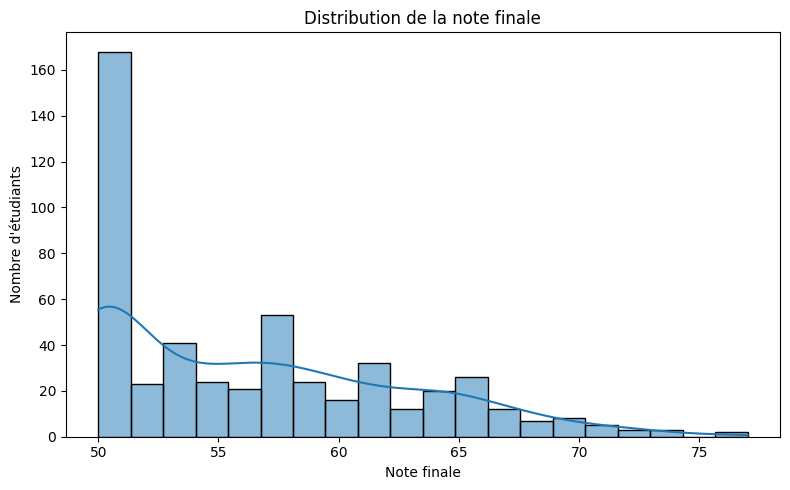

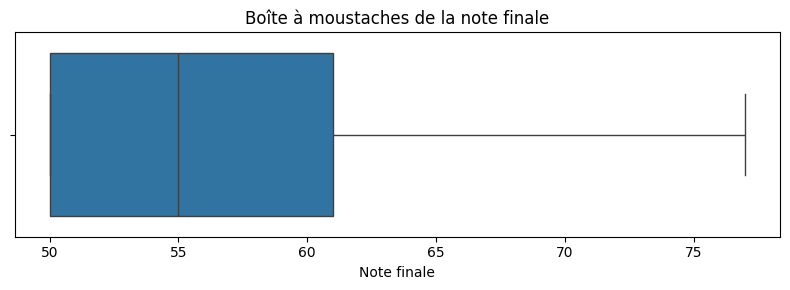

In [13]:
#distribution de la cible
#Histogramme de la cible : « Comment les notes finales sont-elles réparties ? »
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="final_exam_score",
    bins=20,
    kde=True
)
plt.title("Distribution de la note finale")
plt.xlabel("Note finale")
plt.ylabel("Nombre d'étudiants")
plt.tight_layout()
plt.show()

#Boxplot de la cible
plt.figure(figsize=(8, 3))
sns.boxplot(x=df_clean[target])
plt.title("Boîte à moustaches de la note finale")
plt.xlabel("Note finale")
plt.tight_layout()
plt.show()

L'histogramme met en évidence la concentration à 50 et l'asymétrie positive de la cible.

Le boxplot complète l'histogramme en résumant la médiane, les quartiles, la dispersion et les éventuelles observations atypiques.

## 10. Détection des valeurs atypiques par la méthode IQR

In [14]:
#détection des outliers sur toutes les variables

def detect_outliers_iqr(data, columns):

    numeric_data = data[columns]

    q1 = numeric_data.quantile(0.25)
    q3 = numeric_data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    n_outliers = (
        (numeric_data < lower_bound) |
        (numeric_data > upper_bound)
    ).sum()

    outlier_summary = pd.DataFrame({
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": n_outliers
    })

    return outlier_summary


outlier_summary = detect_outliers_iqr(
    df_clean,
    numeric_variables
)

display(outlier_summary.round(2))

,q1,q3,iqr,lower_bound,upper_bound,n_outliers
study_hours_per_week,18.00,33.00,15.00,-4.50,55.50,0
attendance_rate,64.96,87.55,22.59,31.08,121.43,0
past_exam_scores,62.00,88.00,26.00,23.00,127.00,0
final_exam_score,50.00,61.00,11.00,33.50,77.50,0


Selon la règle IQR, aucune des quatre variables numériques principales ne présente d'outlier majeur nécessitant un traitement particulier.

Aucune observation supplémentaire n'est supprimée sur la base de cette méthode.

## 11. Distribution des variables numériques explicatives

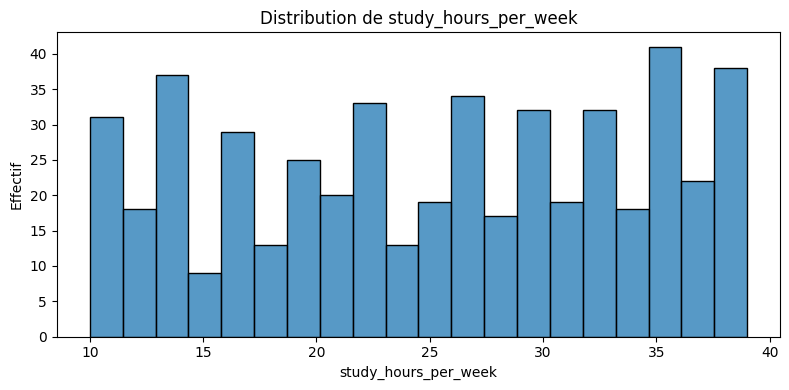

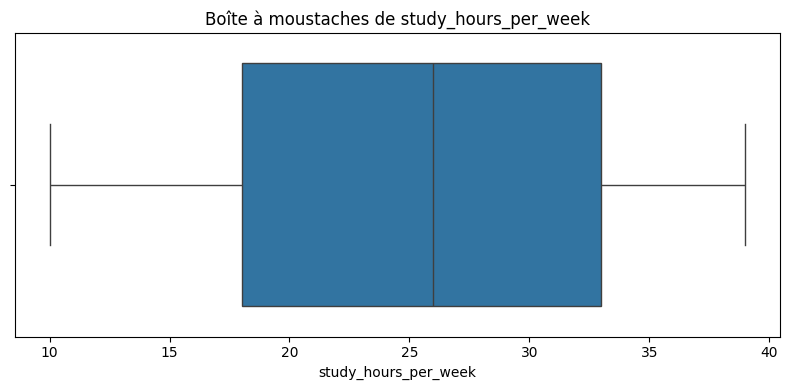

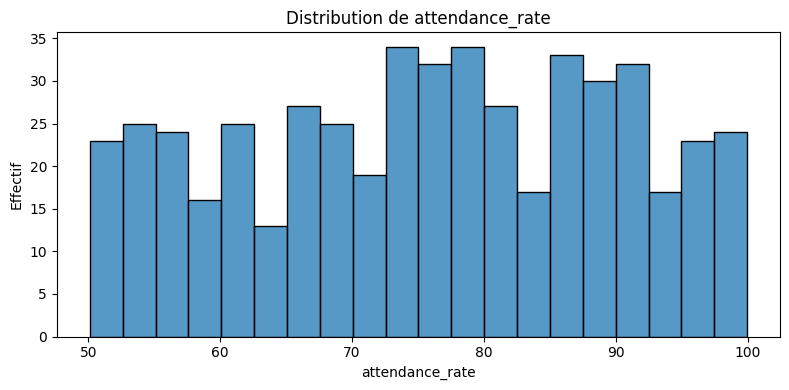

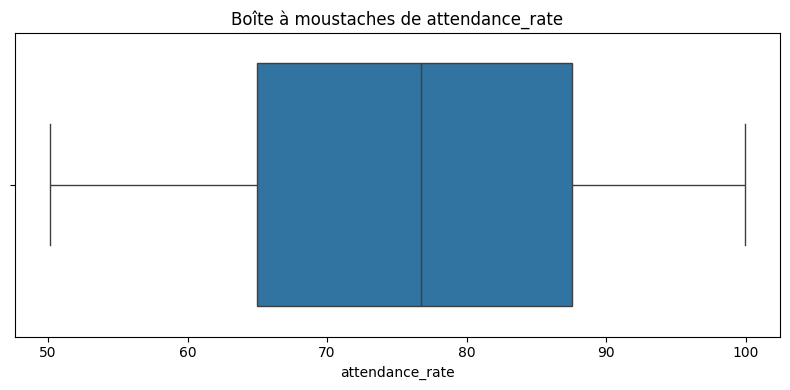

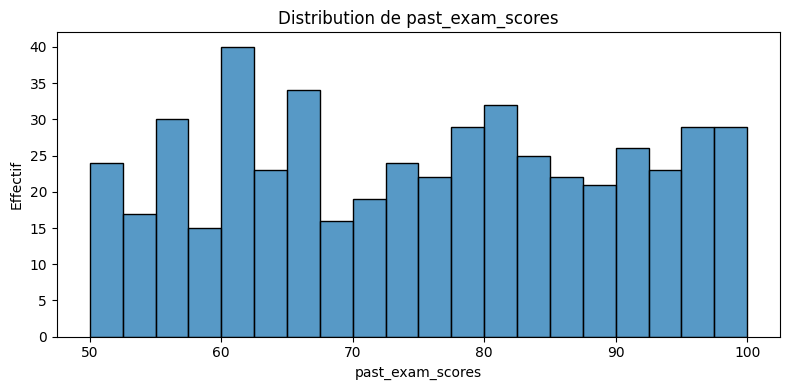

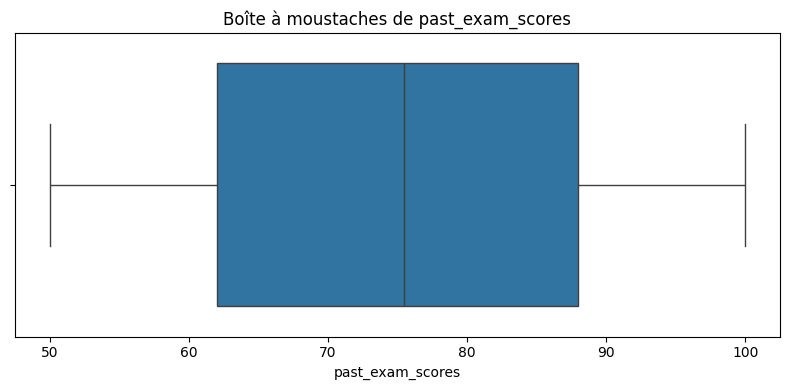

In [15]:
numerical_features = [
    "study_hours_per_week",
    "attendance_rate",
    "past_exam_scores"
]
for feature in numerical_features:
#Pour chacune on génère histogramme puis boxplot

    # Histogramme
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df_clean[numerical_features],
        x=feature,
        bins=20
    )

    plt.title(f"Distribution de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()


    # Boxplot
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        x=df_clean[feature]
    )
    plt.title(f"Boîte à moustaches de {feature}")
    plt.tight_layout()
    plt.show()


Les trois variables numériques explicatives présentent des plages de valeurs cohérentes et une variabilité suffisante.

Aucune anomalie majeure n'impose une transformation ou une suppression immédiate à ce stade. Une éventuelle standardisation pourra toutefois être décidée lors de la Phase 2 selon les modèles utilisés.

## 12. Analyse des variables catégorielles

Analyse de la variable : gender

Valeurs uniques :
['Male' 'Female']

Cardinalité :
2

Fréquences absolues :
gender
Female    256
Male      244
Name: count, dtype: int64

Proportions (%) :
gender
Female    51.2
Male      48.8
Name: proportion, dtype: float64

Mode :
Female


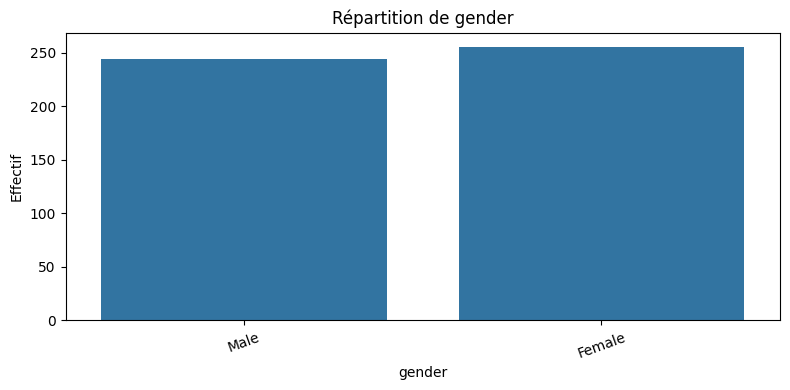



Analyse de la variable : parental_education_level

Valeurs uniques :
['High School' 'PhD' 'Bachelors' 'Masters']

Cardinalité :
4

Fréquences absolues :
parental_education_level
High School    135
Bachelors      127
PhD            121
Masters        117
Name: count, dtype: int64

Proportions (%) :
parental_education_level
High School    27.0
Bachelors      25.4
PhD            24.2
Masters        23.4
Name: proportion, dtype: float64

Mode :
High School


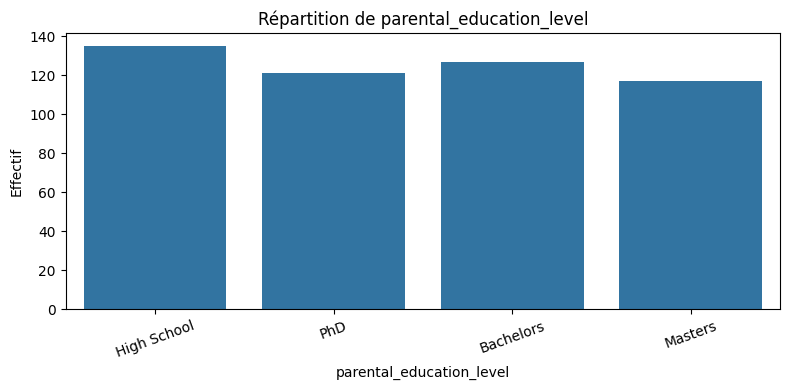



Analyse de la variable : internet_access_at_home

Valeurs uniques :
['Yes' 'No']

Cardinalité :
2

Fréquences absolues :
internet_access_at_home
No     263
Yes    237
Name: count, dtype: int64

Proportions (%) :
internet_access_at_home
No     52.6
Yes    47.4
Name: proportion, dtype: float64

Mode :
No


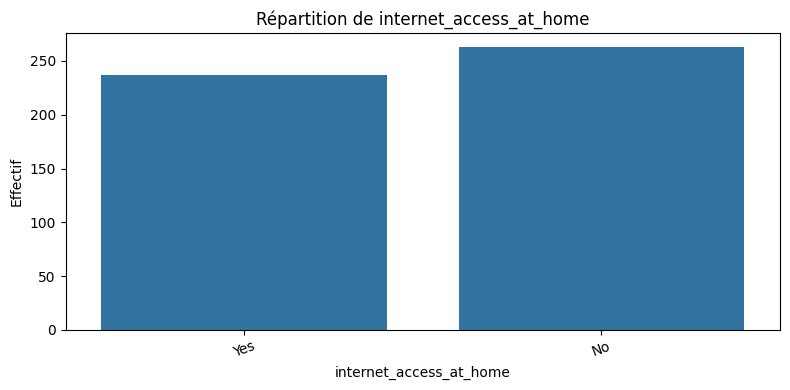



Analyse de la variable : extracurricular_activities

Valeurs uniques :
['Yes' 'No']

Cardinalité :
2

Fréquences absolues :
extracurricular_activities
No     268
Yes    232
Name: count, dtype: int64

Proportions (%) :
extracurricular_activities
No     53.6
Yes    46.4
Name: proportion, dtype: float64

Mode :
No


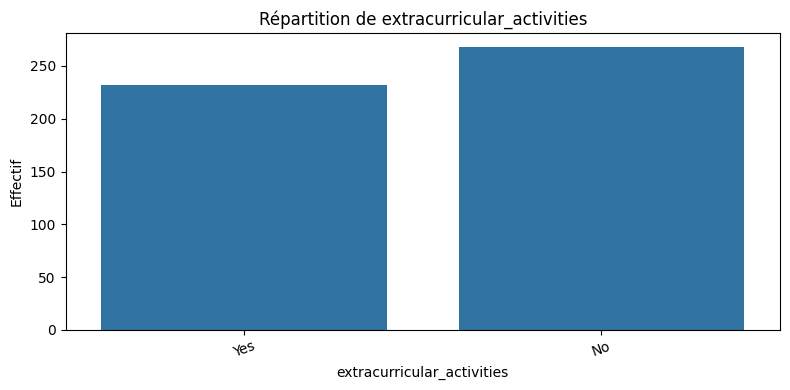



Analyse de la variable : pass_fail

Valeurs uniques :
['Pass' 'Fail']

Cardinalité :
2

Fréquences absolues :
pass_fail
Fail    354
Pass    146
Name: count, dtype: int64

Proportions (%) :
pass_fail
Fail    70.8
Pass    29.2
Name: proportion, dtype: float64

Mode :
Fail


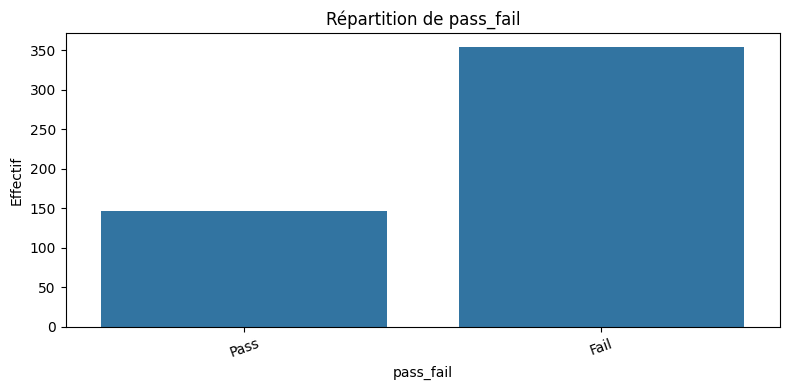

In [16]:
# Variables catégorielles
categorical_features = [
    "gender",
    "parental_education_level",
    "internet_access_at_home",
    "extracurricular_activities"
]
categorical_variables = categorical_features + ["pass_fail"]

for feature in categorical_variables:

    print("=" * 50)
    print(f"Analyse de la variable : {feature}")
    print("=" * 50)

    print("\nValeurs uniques :")
    print(df_clean[feature].unique())

    print("\nCardinalité :")
    print(df_clean[feature].nunique(dropna=True))

    print("\nFréquences absolues :")
    print(df_clean[feature].value_counts(dropna=False))

    print("\nProportions (%) :")
    print(
        df_clean[feature]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    print("\nMode :")
    print(df_clean[feature].mode()[0])

    # countplot dessine nombre dans chaque catégorie.
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df_clean,
        x=feature
    )

    plt.title(f"Répartition de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Effectif")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print("\n")

Les variables `gender`, `internet_access_at_home` et `extracurricular_activities` ne présentent pas de catégorie extrêmement rare. Le niveau d'éducation parentale est également réparti entre plusieurs modalités.

La variable `pass_fail` est plus déséquilibrée, avec environ **70,8 % de Fail** contre **29,2 % de Pass**. Elle est conservée uniquement pour l'analyse exploratoire à ce stade et sera étudiée séparément vis-à-vis de la cible.


## 13. Relations entre les variables numériques et la cible

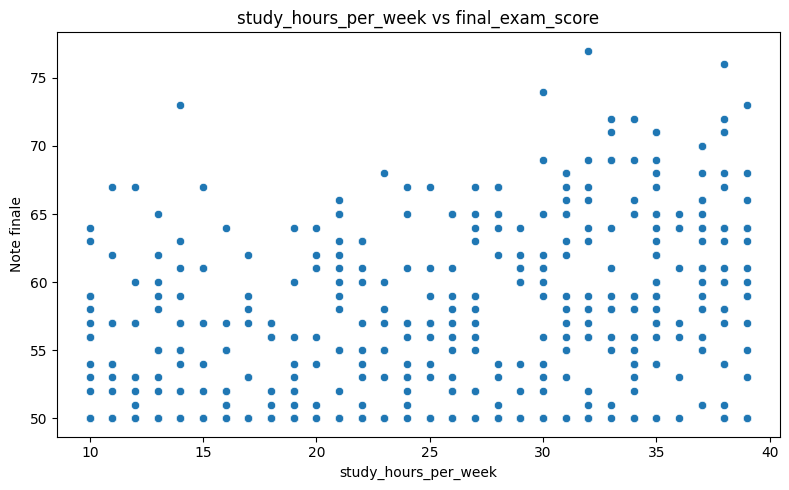

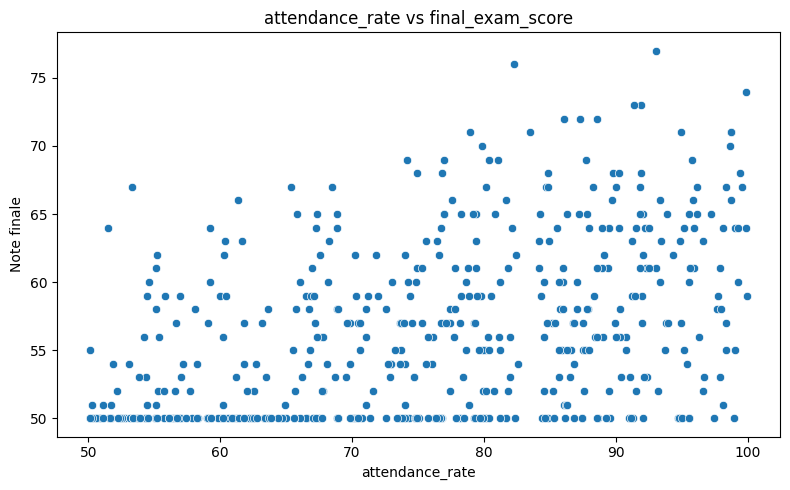

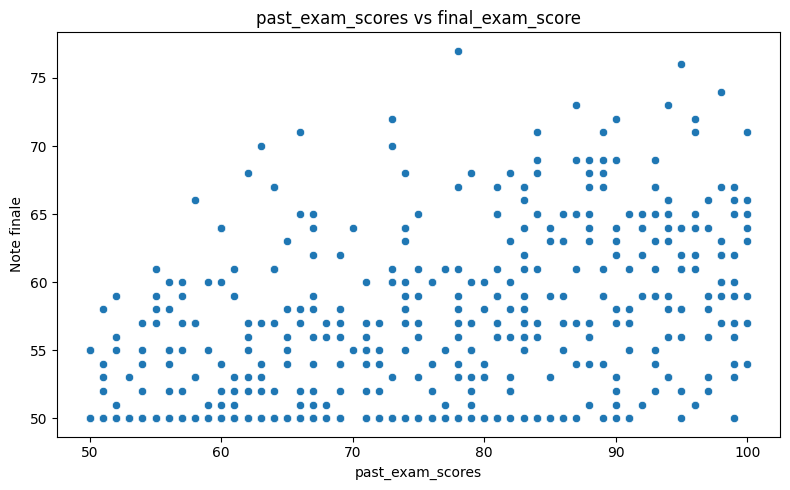

In [17]:
#Viables numériques vs cible

for feature in numerical_features:

#Scatterplot = nuage de points. chaque point est un etudiant
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df_clean,
        x=feature,
        y=target
    )
    plt.title(f"{feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel("Note finale")
    plt.tight_layout()
    plt.show()



In [18]:
correlation_matrix = df_clean[
    numerical_features + [target]
].corr()

display(correlation_matrix.round(3))

,study_hours_per_week,attendance_rate,past_exam_scores,final_exam_score
study_hours_per_week,1.000,-0.040,-0.013,0.375
attendance_rate,-0.040,1.000,-0.023,0.436
past_exam_scores,-0.013,-0.023,1.000,0.474
final_exam_score,0.375,0.436,0.474,1.000


Les trois variables numériques explicatives présentent une corrélation linéaire positive avec la note finale :

- `past_exam_scores` : **r ≈ 0,47** ;
- `attendance_rate` : **r ≈ 0,44** ;
- `study_hours_per_week` : **r ≈ 0,37**.

Ces associations sont modérées : aucune variable n'explique à elle seule l'ensemble de la variabilité de la note finale.

Ces corrélations décrivent des associations statistiques et ne permettent pas de conclure à une relation de causalité.


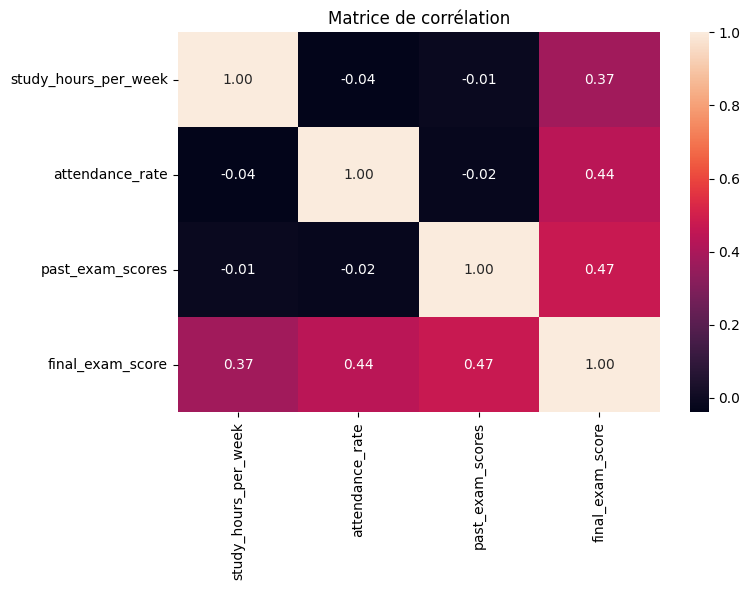

In [19]:
#heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

La heatmap confirme les associations positives avec la cible.

Aucune corrélation extrêmement élevée n'apparaît entre les variables explicatives numériques, ce qui ne met pas en évidence de forte redondance linéaire entre elles.

## 14. Relations entre les variables catégorielles et la cible

gender vs final_exam_score


,count,mean,median,std
gender,,,,
Female,256,56.488,55.0,6.518
Male,244,56.262,55.5,6.002


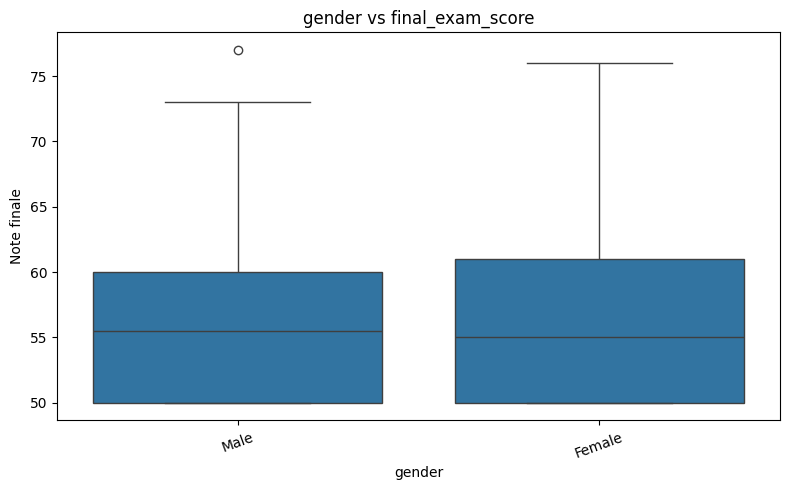

parental_education_level vs final_exam_score


,count,mean,median,std
parental_education_level,,,,
Bachelors,127,56.220,55.0,6.383
High School,135,56.230,55.0,6.022
Masters,117,57.000,56.0,6.801
PhD,121,56.107,55.0,5.899


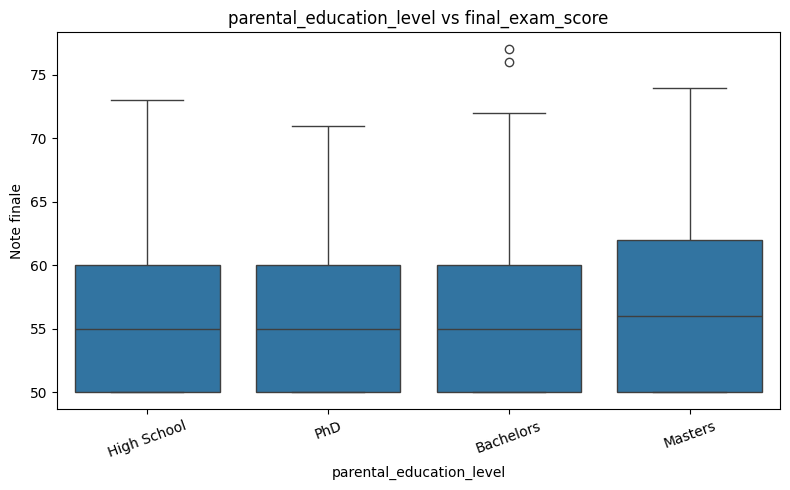

internet_access_at_home vs final_exam_score


,count,mean,median,std
internet_access_at_home,,,,
No,263,56.506,56.0,6.245
Yes,237,56.236,55.0,6.301


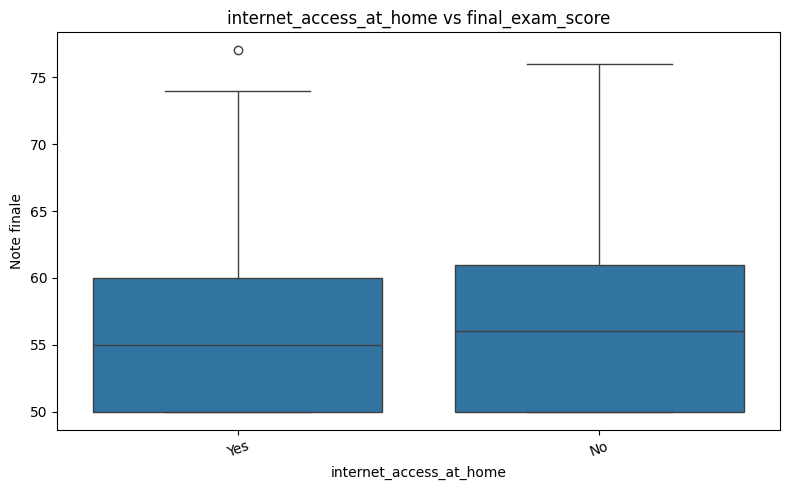

extracurricular_activities vs final_exam_score


,count,mean,median,std
extracurricular_activities,,,,
No,268,56.119,55.0,6.177
Yes,232,56.677,55.0,6.369


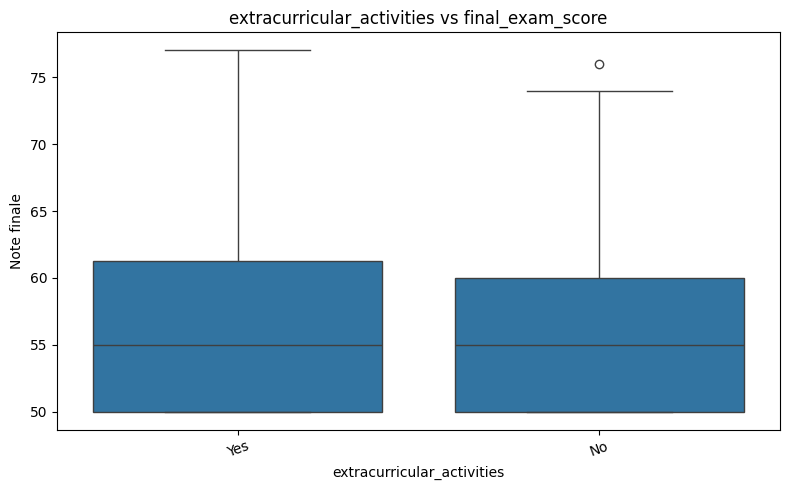

In [20]:
#variables catégorielles vs cible

for feature in categorical_features:
    print("=" * 60)
    print(f"{feature} vs {target}")
    print("=" * 60)

    stats = (
        df_clean
        .groupby(feature)[target]
        .agg(["count", "mean", "median", "std"])
        .round(3)
    )

    display(stats)

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x=feature, y=target)
    plt.title(f"{feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel("Note finale")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

Pour `gender`, `internet_access_at_home`, `extracurricular_activities` et `parental_education_level`, les moyennes de `final_exam_score` restent relativement proches entre les différentes modalités.

Ces résultats sont uniquement descriptifs. La contribution réelle de ces variables à la prédiction devra être évaluée pendant la modélisation.

## 15. Vérification de `pass_fail` et détection du target leakage

In [21]:
pass_fail_check = pd.crosstab(
    df_clean["final_exam_score"],
    df_clean["pass_fail"]
)

display(pass_fail_check)

# Vérification automatique de la règle observée
expected_pass_fail = np.where(df_clean[target] >= 60, "Pass", "Fail")
n_inconsistencies = (df_clean["pass_fail"].to_numpy() != expected_pass_fail).sum()

print(f"Nombre d'incohérences avec la règle score >= 60 → Pass : {n_inconsistencies}")


pass_fail,Fail,Pass
final_exam_score,,
50,154,0
51,14,0
52,23,0
53,21,0
54,20,0
55,24,0
56,21,0
57,34,0
58,19,0


Nombre d'incohérences avec la règle score >= 60 → Pass : 0


L'analyse croisée montre une règle déterministe :

- `final_exam_score < 60` → `Fail` ;
- `final_exam_score >= 60` → `Pass`.

Aucune contradiction n'est observée dans le dataset nettoyé.

`pass_fail` est donc directement dérivée de la variable cible. Son utilisation comme variable explicative introduirait une **fuite d'information (target leakage)** et produirait une évaluation artificiellement optimiste du modèle.

Elle doit être exclue des variables d'entrée avant l'entraînement.

## 17. État final du dataset après la Phase 1

In [22]:
phase1_summary = pd.DataFrame.from_dict(
    {
        "lignes_brutes": len(df_original),
        "colonnes_brutes": df_original.shape[1],
        "doublons_supprimes": len(df_original) - len(df_clean),
        "lignes_finales": len(df_clean),
        "student_id_uniques": df_clean["student_id"].nunique(),
        "valeurs_manquantes": int(df_clean.isna().sum().sum()),
        "doublons_restants": int(df_clean.duplicated().sum())
    },
    orient="index",
    columns=["valeur"]
)

display(phase1_summary)

,valeur
lignes_brutes,708
colonnes_brutes,10
doublons_supprimes,208
lignes_finales,500
student_id_uniques,500
valeurs_manquantes,0
doublons_restants,0


## Conclusion de la Phase 1

La Phase 1 a permis de comprendre, contrôler et explorer le dataset avant toute modélisation.

Le dataset brut contient **708 observations et 10 variables**. L'analyse met en évidence **208 doublons exacts**, dont la suppression conduit à un dataset propre de **500 étudiants uniques**.

Aucune valeur manquante ni incohérence majeure n'est détectée dans les variables numériques et catégorielles contrôlées.

La variable cible `final_exam_score` est comprise entre **50 et 77**, avec une moyenne d'environ **56,38**. Une concentration particulière est observée à la note **50**, qui représente **30,8 %** du dataset nettoyé.

Les variables numériques `past_exam_scores`, `attendance_rate` et `study_hours_per_week` présentent des corrélations positives modérées avec la note finale.

Enfin, deux variables ne devront pas être utilisées comme entrées du modèle :

- `student_id`, car il s'agit d'un identifiant ;
- `pass_fail`, car elle est directement dérivée de `final_exam_score` et provoquerait une fuite d'information.

Le dataset est maintenant prêt pour la **Phase 2 : préparation des données, encodage, standardisation éventuelle et séparation train/test**.


# Phase 2 — Préparation des données pour le Machine Learning

Après l'exploration et le nettoyage réalisés durant la Phase 1, les données doivent être préparées avant l'entraînement des modèles.

Cette phase comprend :

- la séparation des variables explicatives et de la variable cible ;
- la division des données en ensembles d'entraînement et de test ;
- l'identification des variables numériques et catégorielles ;
- la définition de la standardisation des variables numériques ;
- la définition de l'encodage des variables catégorielles.

La variable cible est `final_exam_score`.

Les variables `student_id` et `pass_fail` ne sont pas utilisées comme entrées du modèle :
- `student_id` est uniquement un identifiant ;
- `pass_fail` dépend directement de la note finale et pourrait provoquer une fuite d'information.

## Séparation des variables explicatives et de la cible

La variable à prédire est `final_exam_score`.

Les autres variables utiles sont regroupées dans `X`, tandis que la variable cible est stockée dans `y`.

In [23]:
# Variable cible
y = df_clean["final_exam_score"]

# Variables explicatives
X = df_clean.drop(
    columns=[
        "final_exam_score",
        "student_id",
        "pass_fail"
    ]
)

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (500, 7)
Dimensions de y : (500,)


### Interprétation

Le dataset contient 500 observations et 7 variables explicatives.

La variable `final_exam_score` constitue la cible à prédire, tandis que `student_id` et `pass_fail` ont été exclues des variables d'entrée.

## Vérification de la séparation

Nous vérifions les variables contenues dans `X` ainsi que les premières observations afin de confirmer que la séparation a été réalisée correctement.

In [24]:
print("Colonnes utilisées dans X :")
print(X.columns.tolist())

print("\nAperçu de X :")
display(X.head())

print("\nAperçu de y :")
display(y.head())

Colonnes utilisées dans X :
['gender', 'study_hours_per_week', 'attendance_rate', 'past_exam_scores', 'parental_education_level', 'internet_access_at_home', 'extracurricular_activities']

Aperçu de X :


,gender,study_hours_per_week,attendance_rate,past_exam_scores,parental_education_level,internet_access_at_home,extracurricular_activities
0,Male,31,68.267841,86,High School,Yes,Yes
1,Male,16,78.222927,73,PhD,No,No
2,Female,21,87.525096,74,PhD,Yes,No
3,Female,27,92.076483,99,Bachelors,No,No
4,Female,37,98.655517,63,Masters,No,Yes



Aperçu de y :


,final_exam_score
0,63
1,50
2,55
3,65
4,70


## Vérification de la séparation

Nous vérifions les variables contenues dans `X` ainsi que les premières observations afin de confirmer que la séparation a été réalisée correctement.

## Séparation des données en ensembles d'entraînement et de test

Les données sont divisées en deux ensembles :

- **80 % pour l'entraînement** : utilisés pour apprendre les modèles ;
- **20 % pour le test** : utilisés pour évaluer les modèles sur des données non utilisées pendant l'entraînement.

Cette séparation permet d'évaluer la capacité des modèles à généraliser sur de nouvelles observations.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dimensions des ensembles :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Dimensions des ensembles :
X_train : (400, 7)
X_test  : (100, 7)
y_train : (400,)
y_test  : (100,)


### Interprétation

Le dataset a été divisé en 400 observations pour l'entraînement et 100 observations pour le test.

Le modèle sera entraîné uniquement sur les données d'entraînement. Les données de test seront conservées à part afin d'évaluer ses performances de manière indépendante.

## Identification des variables numériques et catégorielles

Les variables explicatives sont de deux types :

- les variables numériques, qui nécessitent une standardisation ;
- les variables catégorielles, qui nécessitent un encodage.

Cette distinction permet d'appliquer un prétraitement adapté à chaque groupe de variables.

In [26]:
# Variables numériques
numeric_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

# Variables catégorielles
categorical_features = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

print("Variables numériques :")
print(numeric_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['study_hours_per_week', 'attendance_rate', 'past_exam_scores']

Variables catégorielles :
['gender', 'parental_education_level', 'internet_access_at_home', 'extracurricular_activities']


### Interprétation

Les variables explicatives sont composées de 3 variables numériques et de 4 variables catégorielles.

Un traitement différent sera appliqué à chaque groupe avant l'entraînement des modèles.

## Définition du prétraitement

Avant l'entraînement des modèles :

- les variables numériques seront standardisées avec `StandardScaler` ;
- les variables catégorielles seront encodées avec `OneHotEncoder`.

`ColumnTransformer` permet de regrouper ces deux traitements dans un seul préprocesseur.

Le préprocesseur sera ensuite intégré aux pipelines de Machine Learning afin que les transformations soient apprises uniquement à partir des données d'entraînement.

In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


In [28]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['study_hours_per_week', 'attendance_rate',
                                  'past_exam_scores']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'parental_education_level',
                                  'internet_access_at_home',
                                  'extracurricular_activities'])])

### Interprétation

Le préprocesseur est maintenant configuré pour appliquer automatiquement la standardisation aux variables numériques et l'encodage One-Hot aux variables catégorielles.

Il sera intégré directement aux modèles lors de la phase de modélisation afin d'éviter les répétitions et les fuites d'information.

## Conclusion de la Phase 2

La préparation des données est terminée.

Les données ont été séparées en variables explicatives et variable cible, puis divisées en ensembles d'entraînement et de test selon une répartition 80/20.

Les variables numériques et catégorielles ont également été identifiées.

Enfin, un préprocesseur a été configuré pour :

- standardiser les variables numériques avec `StandardScaler` ;
- encoder les variables catégorielles avec `OneHotEncoder`.

Ce préprocesseur sera intégré directement aux pipelines des modèles durant la Phase 3. Cette organisation permet d'automatiser les transformations et d'éviter toute fuite d'information entre les données d'entraînement et de test.

## Conclusion de la Phase 2

La préparation des données est terminée.

Les données ont été séparées en variables explicatives et variable cible, puis divisées en ensembles d'entraînement et de test selon une répartition 80/20.

Les variables numériques et catégorielles ont également été identifiées.

Enfin, un préprocesseur a été configuré pour :

- standardiser les variables numériques avec `StandardScaler` ;
- encoder les variables catégorielles avec `OneHotEncoder`.

Ce préprocesseur sera intégré directement aux pipelines des modèles durant la Phase 3. Cette organisation permet d'automatiser les transformations et d'éviter toute fuite d'information entre les données d'entraînement et de test.

# Phase 3 — Modélisation et évaluation

Après la préparation des données, nous passons à l'entraînement et à l'évaluation des modèles de Machine Learning.

L'objectif est de prédire la variable `final_exam_score` à partir des caractéristiques de l'étudiant.

Trois modèles de régression seront étudiés :

- Régression Linéaire ;
- Random Forest Regressor ;
- XGBoost Regressor.

Pour chaque modèle, le prétraitement des données et l'algorithme seront regroupés dans un `Pipeline`.

Cette approche permet d'appliquer automatiquement le même prétraitement aux données et d'éviter les erreurs ou les fuites d'information.

Les performances des modèles seront ensuite comparées à l'aide des métriques MAE, MSE et R².

## Modèle 1 — Régression Linéaire

La Régression Linéaire est utilisée comme premier modèle de référence.

Le prétraitement défini durant la Phase 2 est intégré directement au modèle à l'aide d'un `Pipeline`.

Le pipeline réalisera automatiquement deux étapes :

1. préparation des variables avec `preprocessor` ;
2. apprentissage avec `LinearRegression`.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['study_hours_per_week',
                                                   'attendance_rate',
                                                   'past_exam_scores']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education_level',
                                                   'internet_access_at_home',
                                                   'extracurricular_activities'])])),
                ('model', LinearRegression())])

### Interprétation

Le pipeline de Régression Linéaire regroupe le prétraitement des données et le modèle dans une seule structure.

Cette organisation garantit que les mêmes transformations seront appliquées automatiquement lors de l'entraînement et des prédictions.

### Entraînement du modèle

Le pipeline de Régression Linéaire est entraîné à partir des données d'entraînement.

Pendant cette étape, le préprocesseur apprend les transformations nécessaires à partir de `X_train`, puis la Régression Linéaire apprend la relation entre les variables explicatives et la note finale `y_train`.

In [30]:
linear_pipeline.fit(X_train, y_train)
print("Régression Linéaire entraînée avec succès.")

Régression Linéaire entraînée avec succès.


### Interprétation

La Régression Linéaire a été entraînée sur les données d'entraînement.

Le prétraitement et l'apprentissage du modèle ont été réalisés automatiquement à l'intérieur du pipeline, sans utiliser les données de test.

### Prédiction sur les données de test

Après l'entraînement, le pipeline est utilisé pour prédire les notes finales des étudiants appartenant à l'ensemble de test.

Les prédictions obtenues seront ensuite comparées aux vraies valeurs de `y_test`.

In [31]:
y_pred_linear = linear_pipeline.predict(X_test)

print("5 premières vraies notes :")
print(y_test.head().values)

print("\n5 premières notes prédites :")
print(y_pred_linear[:5])

5 premières vraies notes :
[51 63 50 55 66]

5 premières notes prédites :
[52.74557799 59.10827681 51.06417516 54.79560394 55.49282197]


### Interprétation

Le modèle a généré une prédiction pour chaque observation de l'ensemble de test.

La comparaison entre les vraies notes et les notes prédites permet d'obtenir une première idée de la qualité des prédictions avant le calcul des métriques d'évaluation.

### Comparaison des notes réelles et prédites

Afin de visualiser les résultats du modèle, nous comparons les notes réelles des étudiants avec les notes prédites par la Régression Linéaire.

Cette comparaison permet d'observer directement l'écart entre la valeur réelle et la prédiction du modèle.

In [32]:
comparison_linear = pd.DataFrame({
    "Note réelle": y_test.values,
    "Note prédite": y_pred_linear
})

comparison_linear["Erreur absolue"] = abs(
    comparison_linear["Note réelle"] - comparison_linear["Note prédite"]
)

comparison_linear.head(10)

,Note réelle,Note prédite,Erreur absolue
0,51,52.745578,1.745578
1,63,59.108277,3.891723
2,50,51.064175,1.064175
3,55,54.795604,0.204396
4,66,55.492822,10.507178
5,50,47.835711,2.164289
6,50,55.545381,5.545381
7,68,63.450618,4.549382
8,50,49.072690,0.927310
9,59,57.579797,1.420203


### Interprétation

Le tableau permet de comparer directement les notes réelles aux notes prédites par le modèle.

L'erreur absolue indique, pour chaque étudiant, la différence en points entre la prédiction et la valeur réelle. Plus cette erreur est faible, plus la prédiction est précise.

### Évaluation de la Régression Linéaire

Les performances du modèle sont évaluées à l'aide de trois métriques :

- **MAE (Mean Absolute Error)** : erreur moyenne en points entre les valeurs réelles et prédites ;
- **MSE (Mean Squared Error)** : moyenne des erreurs au carré, qui pénalise davantage les grandes erreurs ;
- **R² (coefficient de détermination)** : proportion de la variabilité de la note finale expliquée par le modèle.

R² = 1 - (erreurs du modèle / erreurs obtenues si on utilisait simplement la moyenne)

Une MAE et une MSE faibles indiquent de meilleures prédictions, tandis qu'un R² proche de 1 indique un meilleur ajustement du modèle.

In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Performance de la Régression Linéaire")
print(f"MAE : {mae_linear:.2f}")
print(f"MSE : {mse_linear:.2f}")
print(f"R²  : {r2_linear:.3f}")

Performance de la Régression Linéaire
MAE : 3.07
MSE : 14.47
R²  : 0.563


R² proche de 1 → très bon

R² proche de 0 → faible pouvoir explicatif

R² < 0         → modèle très mauvais

### Interprétation des performances

La Régression Linéaire obtient une MAE d'environ 3 points, ce qui signifie que ses prédictions s'écartent en moyenne d'environ 3 points des notes réelles.

Le coefficient R² d'environ 0,56 indique que le modèle explique près de 56 % de la variabilité de la note finale.

Ces résultats constituent une première référence qui sera utilisée pour comparer les performances des autres modèles.

## Modèle 2 — Random Forest Regressor

Le deuxième modèle étudié est le `RandomForestRegressor`.

Contrairement à la Régression Linéaire, Random Forest combine plusieurs arbres de décision. Il peut ainsi modéliser des relations plus complexes et non linéaires entre les caractéristiques des étudiants et leur note finale.

Comme pour le modèle précédent, le prétraitement et le modèle sont regroupés dans un `Pipeline`.

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['study_hours_per_week',
                                                   'attendance_rate',
                                                   'past_exam_scores']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education_level',
                                                   'internet_access_at_home',
                                                   'extracurricular_activities'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

### Interprétation

Le pipeline Random Forest est maintenant configuré avec 100 arbres de décision.

Le prétraitement et le modèle sont regroupés dans une même structure afin d'automatiser la préparation des données avant l'apprentissage.

### Entraînement et prédiction

Le pipeline Random Forest est entraîné sur les données d'entraînement.

Une fois entraîné, il est utilisé pour prédire les notes finales des étudiants de l'ensemble de test.

In [35]:
# Entraîner le pipeline Random Forest
rf_pipeline.fit(X_train, y_train)

# Réaliser les prédictions sur les données de test
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest entraîné avec succès.")
print("Nombre de prédictions :", len(y_pred_rf))
print("5 premières prédictions :", y_pred_rf[:5].round(2))

Random Forest entraîné avec succès.
Nombre de prédictions : 100
5 premières prédictions : [51.81 57.49 52.64 52.22 53.32]


### Interprétation

Le modèle Random Forest a été entraîné sur les données d'entraînement et a généré une prédiction pour chacune des 100 observations de l'ensemble de test.

Le prétraitement a été appliqué automatiquement à l'intérieur du pipeline, sans utiliser les données de test pendant l'apprentissage.

### Évaluation du Random Forest

Les performances du Random Forest sont évaluées à l'aide des mêmes métriques que la Régression Linéaire : MAE, MSE et R².

L'utilisation des mêmes métriques permet de comparer objectivement les différents modèles.

In [36]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Performance du Random Forest")
print("----------------------------")
print(f"MAE : {mae_rf:.2f}")
print(f"MSE : {mse_rf:.2f}")
print(f"R²  : {r2_rf:.3f}")

Performance du Random Forest
----------------------------
MAE : 3.34
MSE : 19.49
R²  : 0.411


### Interprétation

Les métriques obtenues permettent d'évaluer la précision du Random Forest sur les données de test.

Ces résultats seront comparés à ceux de la Régression Linéaire et de XGBoost afin d'identifier le modèle offrant les meilleures performances globales.

## Modèle 3 — XGBoost Regressor

Le troisième modèle étudié est `XGBRegressor`.

XGBoost est un algorithme de boosting qui construit plusieurs arbres de décision de manière successive. Chaque nouvel arbre cherche à corriger les erreurs commises par les arbres précédents.

Comme pour les autres modèles, le prétraitement et l'algorithme sont regroupés dans un `Pipeline`.

In [37]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        (
            "model",
            XGBRegressor(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                objective="reg:squarederror",
                random_state=42
            )
        )
    ]
)

xgb_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['study_hours_per_week',
                                                   'attendance_rate',
                                                   'past_exam_scores']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education_level',
                                                   'internet_access_at_home',
                                                   'extracurricular_activities'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, call...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

### Interprétation

Le pipeline XGBoost est maintenant configuré.

Il combine le prétraitement des données et un modèle `XGBRegressor` composé de plusieurs arbres construits successivement afin d'améliorer progressivement les prédictions.

In [38]:
# Entraîner le pipeline XGBoost
xgb_pipeline.fit(X_train, y_train)

# Réaliser les prédictions sur les données de test
y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost entraîné avec succès.")
print("Nombre de prédictions :", len(y_pred_xgb))
print("5 premières prédictions :", y_pred_xgb[:5].round(2))

XGBoost entraîné avec succès.
Nombre de prédictions : 100
5 premières prédictions : [51.67 57.52 51.62 53.82 53.82]


### Interprétation

Le modèle XGBoost a été entraîné sur les données d'entraînement et a généré une prédiction pour chaque observation de l'ensemble de test.

Comme pour les modèles précédents, le prétraitement des variables est réalisé automatiquement à l'intérieur du pipeline.

### Évaluation de XGBoost

Les performances de XGBoost sont évaluées à l'aide des métriques MAE, MSE et R².

L'utilisation des mêmes métriques pour tous les modèles permettra ensuite de réaliser une comparaison objective de leurs performances.

In [39]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("Performance de XGBoost")
print(f"MAE : {mae_xgb:.2f}")
print(f"MSE : {mse_xgb:.2f}")
print(f"R²  : {r2_xgb:.3f}")

Performance de XGBoost
MAE : 3.07
MSE : 17.13
R²  : 0.482


### Interprétation

XGBoost obtient une erreur moyenne d'environ 3 points sur les notes finales.

Son coefficient R² indique qu'il explique une partie importante de la variabilité des résultats académiques.

Une comparaison globale avec la Régression Linéaire et Random Forest est nécessaire pour déterminer le modèle le plus performant.

## Comparaison des performances des modèles

Les performances de la Régression Linéaire, du Random Forest et de XGBoost sont regroupées dans un même tableau.

La comparaison repose sur trois métriques :

- une **MAE faible** est préférable ;
- une **MSE faible** est préférable ;
- un **R² élevé** est préférable.

Cette comparaison permettra de sélectionner le modèle offrant les meilleures performances globales.

In [40]:
results = pd.DataFrame({
    "Modèle": [
        "Régression Linéaire",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_xgb
    ],
    "MSE": [
        mse_linear,
        mse_rf,
        mse_xgb
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_xgb
    ]
})

# Trier les modèles du meilleur R² au plus faible
results = results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Arrondir les résultats pour faciliter la lecture
results = results.round({
    "MAE": 3,
    "MSE": 3,
    "R²": 3
})

display(results)

,Modèle,MAE,MSE,R²
0,Régression Linéaire,3.067,14.469,0.563
1,XGBoost,3.071,17.128,0.482
2,Random Forest,3.340,19.489,0.411


### Interprétation

Le tableau permet de comparer directement les performances des trois modèles à partir des mêmes données de test et des mêmes métriques.

Le modèle présentant les erreurs les plus faibles et le coefficient R² le plus élevé sera retenu comme modèle final.

## Sélection du meilleur modèle

Après avoir comparé la Régression Linéaire, Random Forest et XGBoost, le modèle présentant les meilleures performances globales est retenu.

Le choix repose principalement sur le coefficient R², tout en tenant compte des valeurs de MAE et de MSE.

In [41]:
# Associer chaque nom de modèle à son pipeline
pipelines = {
    "Régression Linéaire": linear_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

# Le tableau results est déjà trié par R² décroissant
best_model_name = results.iloc[0]["Modèle"]
best_pipeline = pipelines[best_model_name]

best_mae = results.iloc[0]["MAE"]
best_mse = results.iloc[0]["MSE"]
best_r2 = results.iloc[0]["R²"]

print("Modèle retenu :", best_model_name)
print(f"MAE : {best_mae}")
print(f"MSE : {best_mse}")
print(f"R²  : {best_r2}")

Modèle retenu : Régression Linéaire
MAE : 3.067
MSE : 14.469
R²  : 0.563


### Interprétation

La Régression Linéaire est retenue comme meilleur modèle parmi les trois algorithmes testés.

Elle présente le coefficient R² le plus élevé et une erreur quadratique moyenne plus faible que Random Forest et XGBoost.

Ces résultats montrent que, pour ce jeu de données, un modèle relativement simple parvient à mieux généraliser que les modèles basés sur des arbres.

Le modèle sélectionné sera utilisé pour poursuivre l'analyse des facteurs influençant la performance académique.

## Analyse de l'importance des variables

Après la sélection du meilleur modèle, nous analysons l'influence des variables explicatives sur ses prédictions.

La méthode de `Permutation Importance` consiste à modifier aléatoirement les valeurs d'une variable et à mesurer la diminution des performances du modèle.

Si la performance diminue fortement après la permutation d'une variable, cette variable est considérée comme importante pour les prédictions.

In [42]:
from sklearn.inspection import permutation_importance

# Calcul de l'importance des variables
importance = permutation_importance(
    best_pipeline,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="r2"
)

# Création d'un tableau récapitulatif
feature_importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": importance.importances_mean,
    "Écart-type": importance.importances_std
})

# Trier les variables de la plus importante à la moins importante
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.round(3)

,Variable,Importance,Écart-type
0,attendance_rate,0.597,0.092
1,past_exam_scores,0.513,0.060
2,study_hours_per_week,0.350,0.070
3,extracurricular_activities,0.001,0.008
4,parental_education_level,0.000,0.003
5,gender,-0.000,0.000
6,internet_access_at_home,-0.026,0.014


### Interprétation

Les variables situées en haut du tableau sont celles dont la permutation entraîne la plus forte diminution du coefficient R².

Elles jouent donc le rôle le plus important dans les prédictions réalisées par le modèle sélectionné.

À l'inverse, une importance proche de zéro indique qu'une variable contribue peu aux performances prédictives du modèle.

## Conclusion de la Phase 3

Durant cette phase, trois modèles de régression ont été entraînés et évalués afin de prédire la note finale `final_exam_score` :

- la Régression Linéaire ;
- Random Forest Regressor ;
- XGBoost Regressor.

Pour chaque modèle, le prétraitement des données et l'algorithme ont été regroupés dans un `Pipeline`, ce qui permet d'automatiser les transformations et d'éviter toute fuite d'information entre les données d'entraînement et de test.

Les modèles ont été comparés à l'aide des métriques MAE, MSE et R².

D'après les résultats obtenus, la Régression Linéaire présente les meilleures performances globales parmi les modèles testés, avec le coefficient R² le plus élevé et une MSE plus faible.

Elle a donc été retenue comme modèle final pour la suite du projet.

Une analyse par importance de permutation a également été réalisée afin d'identifier les variables qui contribuent le plus aux performances prédictives du modèle.

Cette phase a ainsi permis de sélectionner un modèle de prédiction et d'analyser les facteurs les plus utiles à l'estimation de la performance académique.

# Phase 4 — Développement de l'interface utilisateur

Après la sélection du meilleur modèle de Machine Learning, nous développons une interface utilisateur simple permettant d'effectuer des prédictions sans manipuler directement le code Python.

L'utilisateur pourra renseigner les principales caractéristiques d'un étudiant, notamment ses habitudes d'étude et ses informations académiques, puis lancer une prédiction de sa note finale.

L'interface sera développée avec **Gradio** et utilisera directement le pipeline du modèle sélectionné durant la Phase 3.

Cette approche permet de conserver automatiquement toutes les étapes de prétraitement nécessaires avant la prédiction.

## Fonction de prédiction

Une fonction de prédiction est créée afin de relier les données saisies par l'utilisateur au modèle sélectionné.

Cette fonction transforme les informations saisies en une observation compatible avec le pipeline, puis utilise le modèle pour estimer la note finale de l'étudiant.

In [43]:
def predict_final_score(
    gender,
    study_hours_per_week,
    attendance_rate,
    past_exam_scores,
    parental_education_level,
    internet_access_at_home,
    extracurricular_activities
):
    # Créer une observation avec les informations saisies
    student_data = pd.DataFrame({
        "gender": [gender],
        "study_hours_per_week": [study_hours_per_week],
        "attendance_rate": [attendance_rate],
        "past_exam_scores": [past_exam_scores],
        "parental_education_level": [parental_education_level],
        "internet_access_at_home": [internet_access_at_home],
        "extracurricular_activities": [extracurricular_activities]
    })

    # Prédiction de la note finale
    predicted_score = best_pipeline.predict(student_data)[0]

    # Conversion et arrondi
    predicted_score = round(float(predicted_score), 2)

    # Déterminer Pass ou Fail
    if predicted_score >= 60:
        result = "Pass"
    else:
        result = "Fail"

    # Retourner les deux résultats
    return predicted_score, result

### Interprétation

La fonction `predict_final_score` permet d'utiliser directement le pipeline sélectionné pour prédire la note finale d'un nouvel étudiant.

Toutes les transformations nécessaires sont appliquées automatiquement par le pipeline avant la prédiction.

## Vérification des valeurs disponibles pour l'interface

Avant de construire l'interface, nous vérifions les catégories et les plages de valeurs présentes dans les données d'entraînement.

Ces informations seront utilisées pour configurer les menus déroulants et les champs numériques de l'interface, tout en garantissant leur compatibilité avec le modèle.

In [44]:
# Catégories disponibles dans les données d'entraînement
gender_choices = sorted(
    X_train["gender"].dropna().unique().tolist()
)

parental_education_choices = sorted(
    X_train["parental_education_level"].dropna().unique().tolist()
)

internet_choices = sorted(
    X_train["internet_access_at_home"].dropna().unique().tolist()
)

extracurricular_choices = sorted(
    X_train["extracurricular_activities"].dropna().unique().tolist()
)

# Plages des variables numériques
numeric_ranges = {
    "study_hours_per_week": (
        X_train["study_hours_per_week"].min(),
        X_train["study_hours_per_week"].max()
    ),
    "attendance_rate": (
        X_train["attendance_rate"].min(),
        X_train["attendance_rate"].max()
    ),
    "past_exam_scores": (
        X_train["past_exam_scores"].min(),
        X_train["past_exam_scores"].max()
    )
}

print("Genre :", gender_choices)
print("Niveau d'éducation des parents :", parental_education_choices)
print("Accès à Internet :", internet_choices)
print("Activités extrascolaires :", extracurricular_choices)

print("\nPlages des variables numériques :")
for variable, values in numeric_ranges.items():
    print(f"{variable} : {values[0]:.2f} → {values[1]:.2f}")

Genre : ['Female', 'Male']
Niveau d'éducation des parents : ['Bachelors', 'High School', 'Masters', 'PhD']
Accès à Internet : ['No', 'Yes']
Activités extrascolaires : ['No', 'Yes']

Plages des variables numériques :
study_hours_per_week : 10.00 → 39.00
attendance_rate : 50.12 → 99.97
past_exam_scores : 50.00 → 100.00


### Interprétation

Les catégories et les plages de valeurs nécessaires à l'interface ont été identifiées à partir des données d'entraînement.

Elles permettront de limiter les saisies de l'utilisateur à des valeurs cohérentes avec celles utilisées lors de l'apprentissage du modèle.

## Création de l'interface Gradio

Une interface web est créée avec Gradio afin de permettre à l'utilisateur de renseigner les caractéristiques d'un étudiant et d'obtenir une estimation de sa note finale.

Les champs proposés correspondent exactement aux variables utilisées par le modèle.

Les listes déroulantes utilisent les catégories présentes dans les données d'entraînement, tandis que les variables numériques sont représentées par des curseurs limités aux plages observées.

In [45]:
import gradio as gr

with gr.Blocks(title="Prédiction de la performance académique") as demo:

    gr.Markdown(
        """
        # Prédiction de la performance académique

        Renseignez les informations de l'étudiant puis cliquez sur
        **Prédire** pour obtenir une estimation de sa note finale
        ainsi que son résultat Pass / Fail.
        """
    )

    with gr.Row():

        gender_input = gr.Dropdown(
            choices=gender_choices,
            value=gender_choices[0],
            label="Genre"
        )

        parental_education_input = gr.Dropdown(
            choices=parental_education_choices,
            value=parental_education_choices[0],
            label="Niveau d'éducation des parents"
        )

    with gr.Row():

        study_hours_input = gr.Slider(
            minimum=float(numeric_ranges["study_hours_per_week"][0]),
            maximum=float(numeric_ranges["study_hours_per_week"][1]),
            value=float(X_train["study_hours_per_week"].median()),
            label="Heures d'étude par semaine"
        )

        attendance_input = gr.Slider(
            minimum=float(numeric_ranges["attendance_rate"][0]),
            maximum=float(numeric_ranges["attendance_rate"][1]),
            value=float(X_train["attendance_rate"].median()),
            label="Taux de présence"
        )

        past_scores_input = gr.Slider(
            minimum=float(numeric_ranges["past_exam_scores"][0]),
            maximum=float(numeric_ranges["past_exam_scores"][1]),
            value=float(X_train["past_exam_scores"].median()),
            label="Notes aux examens précédents"
        )

    with gr.Row():

        internet_input = gr.Dropdown(
            choices=internet_choices,
            value=internet_choices[0],
            label="Accès à Internet à domicile"
        )

        extracurricular_input = gr.Dropdown(
            choices=extracurricular_choices,
            value=extracurricular_choices[0],
            label="Activités extrascolaires"
        )

    predict_button = gr.Button("Prédire")

    # Premier résultat : note prédite
    predicted_score_output = gr.Number(
        label="Note finale estimée",
        precision=2
    )

    # Deuxième résultat : Pass ou Fail
    pass_fail_output = gr.Textbox(
        label="Résultat",
        interactive=False
    )

    predict_button.click(
        fn=predict_final_score,
        inputs=[
            gender_input,
            study_hours_input,
            attendance_input,
            past_scores_input,
            parental_education_input,
            internet_input,
            extracurricular_input
        ],
        outputs=[
            predicted_score_output,
            pass_fail_output
        ]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3414b71e76fbfa597f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Interprétation

L'interface permet désormais à un utilisateur de saisir les caractéristiques d'un étudiant sans manipuler directement le code Python.

Lorsqu'il clique sur le bouton **Prédire**, les valeurs saisies sont transmises à la fonction de prédiction, puis au pipeline du modèle sélectionné.

Le prétraitement des données et la prédiction sont ainsi réalisés automatiquement, et la note finale estimée est affichée directement dans l'interface.

## Conclusion de la Phase 4

Durant cette phase, une interface utilisateur a été développée avec Gradio afin de rendre le modèle de prédiction accessible sans avoir à manipuler directement le code Python.

L'interface permet à l'utilisateur de renseigner les principales caractéristiques d'un étudiant, puis d'obtenir une estimation de sa note finale en cliquant sur le bouton **Prédire**.

La fonction de prédiction est directement connectée au pipeline du meilleur modèle sélectionné durant la Phase 3. Le prétraitement des données et la prédiction sont ainsi réalisés automatiquement.


Cette phase permet donc de transformer le modèle de Machine Learning en une solution simple et utilisable par un utilisateur final.

In [46]:
import joblib

joblib.dump(
    best_pipeline,
    "student_performance_model.joblib"
)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [47]:
import os

print(os.path.exists("student_performance_model.joblib"))

True


In [48]:
loaded_model = joblib.load(
    "student_performance_model.joblib"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [49]:
student_test = X_test.iloc[[0]]

student_test

,gender,study_hours_per_week,attendance_rate,past_exam_scores,parental_education_level,internet_access_at_home,extracurricular_activities
361,Female,18,86.304779,59,High School,Yes,Yes


In [50]:
prediction_originale = best_pipeline.predict(student_test)[0]

prediction_chargee = loaded_model.predict(student_test)[0]

print("Modèle original :", prediction_originale)
print("Modèle chargé   :", prediction_chargee)

Modèle original : 52.74557799381444
Modèle chargé   : 52.74557799381444


In [51]:
df_clean.to_csv(
    "student_performance_dataset_clean.csv",
    index=False
)

In [52]:
from google.colab import files

files.download(
    "student_performance_dataset_clean.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>